In [2]:
import networkx as nx
import pandas as pd

In [10]:
# Load data
cities = pd.read_csv("cities_roads.csv")          # columns: name, station, lat, lon
connections = pd.read_csv("edges_roads.csv")  # columns: from, to

{'ALM': Text(5.21764, 52.37503, 'ALM'),
 'APN': Text(4.6577777862549, 52.124443054199, 'APN'),
 'AMF': Text(5.3705554008484, 52.153888702393, 'AMF'),
 'ASD': Text(4.9002776145935, 52.378887176514, 'ASD'),
 'DT': Text(4.3563890457153, 52.00666809082, 'DT'),
 'GVC': Text(4.3249998092651, 52.080276489258, 'GVC'),
 'DDR': Text(4.668333530426, 51.807220458984, 'DDR'),
 'GD': Text(4.7044444084167, 52.017501831055, 'GD'),
 'HLM': Text(4.6383333206177, 52.38777923584, 'HLM'),
 'HVS': Text(5.1819443702698, 52.225833892822, 'HVS'),
 'LEDN': Text(4.4816665649414, 52.166110992432, 'LEDN'),
 'RTD': Text(4.468888759613, 51.92499923706, 'RTD'),
 'SHL': Text(4.7619442939758, 52.30944442749, 'SHL'),
 'UT': Text(5.1102776527405, 52.088890075684, 'UT'),
 'WD': Text(4.8936109542847, 52.084999084473, 'WD'),
 'VLR': Text(4.349437, 51.912067, 'VLR'),
 'ZD': Text(4.8136110305786, 52.438888549805, 'ZD'),
 'ZTM': Text(4.4772224426269, 52.047500610352, 'ZTM')}

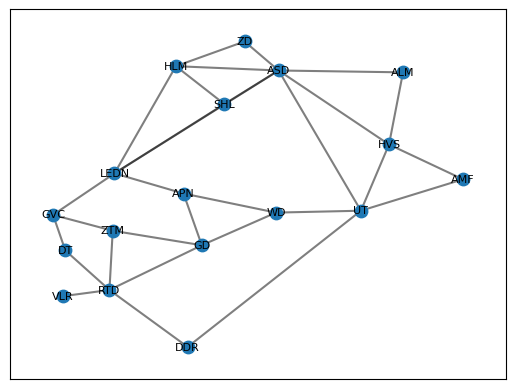

In [11]:
# Make sure coordinates are numeric
cities["lat"] = pd.to_numeric(cities["lat"], errors="coerce")
cities["lng"] = pd.to_numeric(cities["lng"], errors="coerce")

# Remove rows with missing coordinates
cities = cities.dropna(subset=["lat", "lng"])

# Create graph
G = nx.Graph()

# Add nodes
for _, row in cities.iterrows():
    G.add_node(
        row["name"],
        station=row["station"],
        lat=row["lat"],
        lon=row["lng"]
    )

# Add edges only once, even if both ASD-HLM and HLM-ASD exist
seen_edges = set()

for _, row in connections.iterrows():
    a = row["from"]
    b = row["to"]

    if a in G and b in G and a != b:
        edge = tuple(sorted([a, b]))
        if edge not in seen_edges:
            G.add_edge(a, b)
            seen_edges.add(edge)

# Positions
pos = {
    row["name"]: (row["lng"], row["lat"])
    for _, row in cities.iterrows()
}

# Draw
nx.draw_networkx_edges(G, pos, alpha=0.5, width=1.5)
nx.draw_networkx_nodes(G, pos, node_size=80)
nx.draw_networkx_labels(G, pos, font_size=8)